<a href="https://colab.research.google.com/github/AishaniiiRoy/HR_Analytics/blob/main/HR_LR_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

import pandas as pd
import numpy as np
df = pd.read_csv( "hr_data.csv" )
df.info()



Saving hr_data.csv to hr_data.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SLNO                         8995 non-null   int64  
 1   Candidate Ref                8995 non-null   int64  
 2   DOJ Extended                 8995 non-null   object 
 3   Duration to accept offer     8995 non-null   int64  
 4   Notice period                8995 non-null   int64  
 5   Offered band                 8995 non-null   object 
 6   Pecent hike expected in CTC  8995 non-null   float64
 7   Percent hike offered in CTC  8995 non-null   float64
 8   Percent difference CTC       8995 non-null   float64
 9   Joining Bonus                8995 non-null   object 
 10  Candidate relocate actual    8995 non-null   object 
 11  Gender                       8995 non-null   object 
 12  Candidate Source             8995 non-null

In [ ]:
df.head()

,SLNO,Candidate Ref,DOJ Extended,Duration to accept offer,Notice period,Offered band,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Rex in Yrs,LOB,Location,Age,Status
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,ERS,Noida,34,Joined
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,INFRA,Chennai,34,Joined
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,INFRA,Noida,27,Joined
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,INFRA,Noida,34,Joined
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,INFRA,Noida,34,Joined


In [ ]:
df['Status_binary'] = df['Status'].map({'Joined': 0, 'Not Joined': 1})

In [ ]:
df.head()

,SLNO,Candidate Ref,DOJ Extended,Duration to accept offer,Notice period,Offered band,Pecent hike expected in CTC,Percent hike offered in CTC,Percent difference CTC,Joining Bonus,Candidate relocate actual,Gender,Candidate Source,Rex in Yrs,LOB,Location,Age,Status,Status_binary
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,ERS,Noida,34,Joined,0
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,INFRA,Chennai,34,Joined,0
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,INFRA,Noida,27,Joined,0
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,INFRA,Noida,34,Joined,0
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,INFRA,Noida,34,Joined,0


In [ ]:
df.Status_binary.value_counts()


,count
Status_binary,
0,7313
1,1682


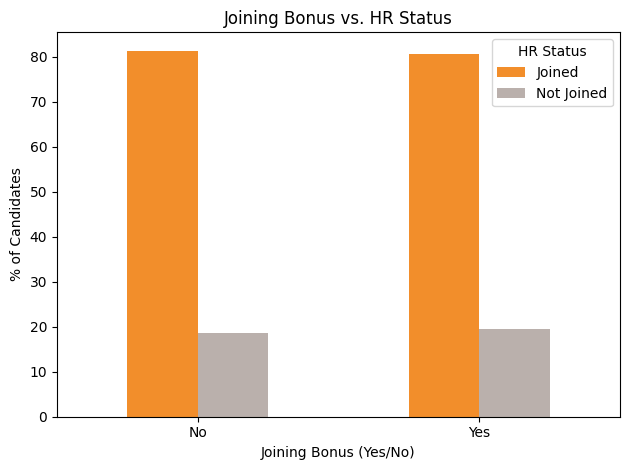

In [ ]:


bonus_status = df.groupby(['Joining Bonus', 'Status_binary']).size().reset_index(name='Count')

# Map 1 to 'Not Joined' and 0 to 'Joined'
bonus_status['HR Status'] = bonus_status['Status_binary'].map({1: 'Not Joined', 0: 'Joined'})

# Calculate percentages
total_by_bonus = bonus_status.groupby('Joining Bonus')['Count'].transform('sum')
bonus_status['Percentage'] = (bonus_status['Count'] / total_by_bonus) * 100

# Pivot for plotting
pivot_bonus = bonus_status.pivot(index='Joining Bonus', columns='HR Status', values='Percentage').fillna(0)
pivot_bonus = pivot_bonus[['Joined', 'Not Joined']]

# Plot
pivot_bonus.plot(kind='bar', stacked=False, color=['#F28E2B', '#BAB0AC'])
plt.title('Joining Bonus vs. HR Status')
plt.xlabel('Joining Bonus (Yes/No)')
plt.ylabel('% of Candidates')
plt.xticks(rotation=0)
plt.legend(title='HR Status')
plt.tight_layout()
plt.show()



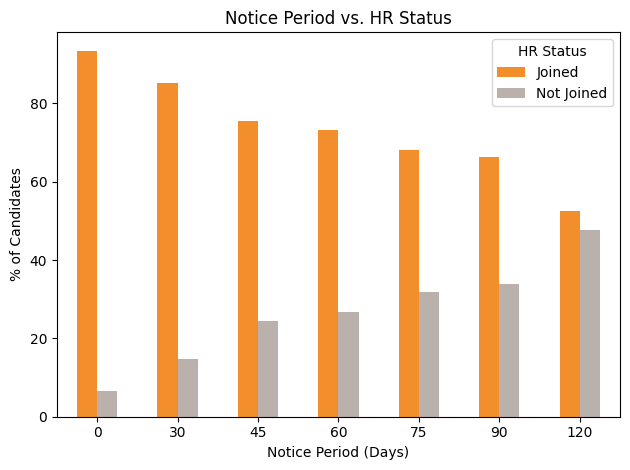

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Plot: Notice Period vs HR Status
notice_status = df.groupby(['Notice period', 'Status_binary']).size().reset_index(name='Count')

# Map 1 to 'Not Joined' and 0 to 'Joined'
notice_status['HR Status'] = notice_status['Status_binary'].map({1: 'Not Joined', 0: 'Joined'})

# Calculate percentages
total_by_notice = notice_status.groupby('Notice period')['Count'].transform('sum')
notice_status['Percentage'] = (notice_status['Count'] / total_by_notice) * 100

# Pivot for plotting
pivot_df = notice_status.pivot(index='Notice period', columns='HR Status', values='Percentage').fillna(0)
pivot_df = pivot_df[['Joined', 'Not Joined']]  # Ensure consistent order

# Plot
pivot_df.plot(kind='bar', stacked=False, color=['#F28E2B', '#BAB0AC'])
plt.title('Notice Period vs. HR Status')
plt.xlabel('Notice Period (Days)')
plt.ylabel('% of Candidates')
plt.xticks(rotation=0)
plt.legend(title='HR Status')
plt.tight_layout()
plt.show()


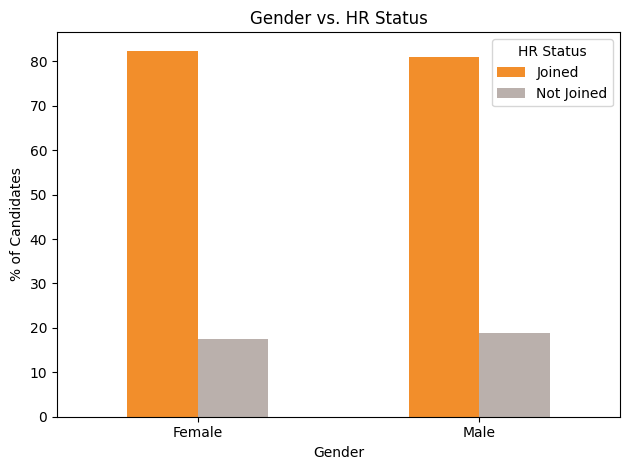

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Map Status_binary: 0 = Joined, 1 = Not Joined
df['HR Status'] = df['Status_binary'].map({0: 'Joined', 1: 'Not Joined'})

# Group by Gender and HR Status
gender_status = df.groupby(['Gender', 'HR Status']).size().reset_index(name='Count')

# Calculate percentage within each Gender group
gender_status['Percentage'] = gender_status.groupby('Gender')['Count'].transform(lambda x: x / x.sum() * 100)

# Pivot table for bar plot
pivot_gender = gender_status.pivot(index='Gender', columns='HR Status', values='Percentage').fillna(0)
pivot_gender = pivot_gender[['Joined', 'Not Joined']]  # ensure correct order

# Plot
pivot_gender.plot(kind='bar', stacked=False, color=['#F28E2B', '#BAB0AC'])
plt.title('Gender vs. HR Status')
plt.xlabel('Gender')
plt.ylabel('% of Candidates')
plt.xticks(rotation=0)
plt.legend(title='HR Status')
plt.tight_layout()
plt.show()


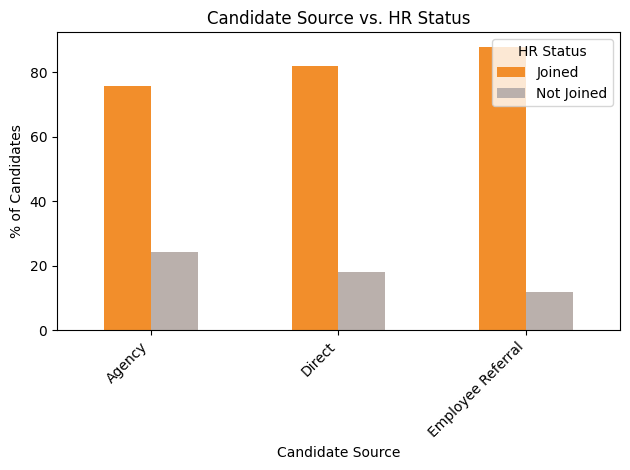

In [ ]:
# Map Status_binary to labels
df['HR Status'] = df['Status_binary'].map({0: 'Joined', 1: 'Not Joined'})

# Group by Candidate Source and HR Status
source_status = df.groupby(['Candidate Source', 'HR Status']).size().reset_index(name='Count')

# Calculate percentages within each Candidate Source
source_status['Percentage'] = source_status.groupby('Candidate Source')['Count'].transform(lambda x: x / x.sum() * 100)

# Pivot for plotting
pivot_source = source_status.pivot(index='Candidate Source', columns='HR Status', values='Percentage').fillna(0)
pivot_source = pivot_source[['Joined', 'Not Joined']]

# Plot
pivot_source.plot(kind='bar', stacked=False, color=['#F28E2B', '#BAB0AC'])
plt.title('Candidate Source vs. HR Status')
plt.xlabel('Candidate Source')
plt.ylabel('% of Candidates')
plt.xticks(rotation=45, ha='right')
plt.legend(title='HR Status')
plt.tight_layout()
plt.show()


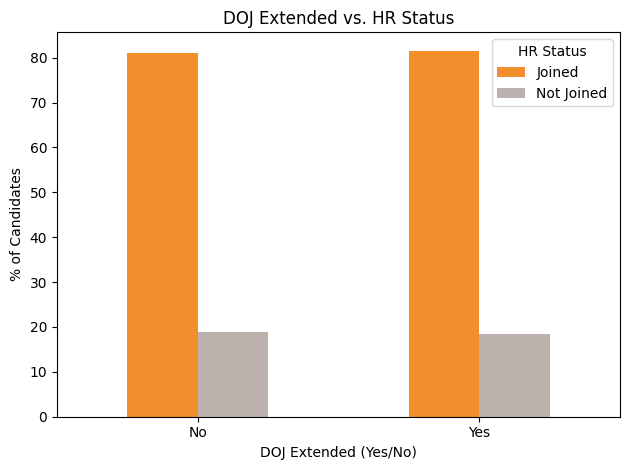

In [ ]:
# Group by DOJ Extended and HR Status
doj_status = df.groupby(['DOJ Extended', 'HR Status']).size().reset_index(name='Count')

# Calculate percentages within each DOJ Extended value
doj_status['Percentage'] = doj_status.groupby('DOJ Extended')['Count'].transform(lambda x: x / x.sum() * 100)

# Pivot for plotting
pivot_doj = doj_status.pivot(index='DOJ Extended', columns='HR Status', values='Percentage').fillna(0)
pivot_doj = pivot_doj[['Joined', 'Not Joined']]

# Plot
pivot_doj.plot(kind='bar', stacked=False, color=['#F28E2B', '#BAB0AC'])
plt.title('DOJ Extended vs. HR Status')
plt.xlabel('DOJ Extended (Yes/No)')
plt.ylabel('% of Candidates')
plt.xticks(rotation=0)
plt.legend(title='HR Status')
plt.tight_layout()
plt.show()


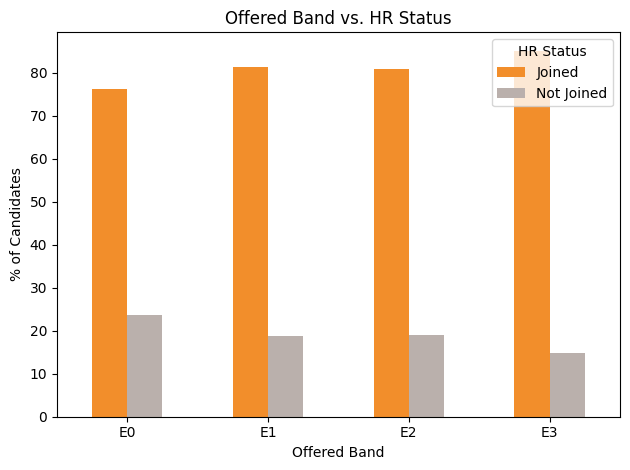

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure readable HR Status
df['HR Status'] = df['Status_binary'].map({0: 'Joined', 1: 'Not Joined'})

# Create a crosstab with counts
band_crosstab = pd.crosstab(df['Offered band'], df['HR Status'])

# Convert to percentages row-wise
band_percent = band_crosstab.div(band_crosstab.sum(axis=1), axis=0) * 100

# Reorder columns to ensure consistent order
band_percent = band_percent[['Joined', 'Not Joined']].fillna(0)

# Plot
band_percent.plot(kind='bar', stacked=False, color=['#F28E2B', '#BAB0AC'])
plt.title('Offered Band vs. HR Status')
plt.xlabel('Offered Band')
plt.ylabel('% of Candidates')
plt.xticks(rotation=0)
plt.legend(title='HR Status')
plt.tight_layout()
plt.show()


In [ ]:
X = df[['DOJ Extended', 'Notice period', 'Candidate Source',
        'Percent difference CTC', 'Age', 'Offered band', 'LOB']]
y = df['Status_binary']

df['Age*Offered_band'] = df['Age'].astype(str) + "_" + df['Offered band'].astype(str)
df['Age*LOB'] = df['Age'].astype(str) + "_" + df['LOB'].astype(str)

X = df[['DOJ Extended', 'Notice period', 'Candidate Source',
        'Percent difference CTC', 'Age*Offered_band', 'Age*LOB']]



In [ ]:


X_features

['Candidate Ref',
 'DOJ Extended',
 'Duration to accept offer',
 'Notice period',
 'Offered band',
 'Pecent hike expected in CTC',
 'Percent hike offered in CTC',
 'Percent difference CTC',
 'Joining Bonus',
 'Candidate relocate actual',
 'Gender',
 'Candidate Source',
 'Rex in Yrs',
 'LOB',
 'Location',
 'Age']

In [ ]:

encoded_df = pd.get_dummies(X, drop_first=True)

In [ ]:
encoded_df.head()

,Notice period,Percent difference CTC,DOJ Extended_Yes,Candidate Source_Direct,Candidate Source_Employee Referral,Age*Offered_band_20_E3,Age*Offered_band_21_E1,Age*Offered_band_22_E0,Age*Offered_band_22_E1,Age*Offered_band_23_E0,...,Age*LOB_48_CSMP,Age*LOB_48_INFRA,Age*LOB_49_AXON,Age*LOB_49_CSMP,Age*LOB_49_EAS,Age*LOB_50_AXON,Age*LOB_50_EAS,Age*LOB_50_INFRA,Age*LOB_51_ERS,Age*LOB_60_ERS
0,30,42.86,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,30,180.00,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,45,0.00,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,30,0.00,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,120,0.00,True,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
import statsmodels.api as sm

X = sm.add_constant( encoded_df )
X = X.astype(float)


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def clean_X_for_logit(X, vif_threshold=10):
    # 1. Keep numeric only
    X = X.select_dtypes(include=[np.number])

    # 2. Drop constant columns
    X = X.loc[:, X.nunique() > 1]

    # 3. Drop exact duplicates
    X = X.T.drop_duplicates().T

    # 4. Function to calculate VIF
    def calc_vif(X):
        X_const = sm.add_constant(X)
        return pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns
        ).drop('const')

    # 5. Combine correlated columns until all VIFs < threshold
    while True:
        vif = calc_vif(X)
        if vif.max() < vif_threshold:
            break
        corr_matrix = X.corr().abs()
        np.fill_diagonal(corr_matrix.values, 0)
        i, j = np.unravel_index(np.argmax(corr_matrix.values), corr_matrix.shape)
        col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
        X[f'{col1}_plus_{col2}'] = X[col1] + X[col2]
        X = X.drop(columns=[col1, col2])

    return sm.add_constant(X.astype(float))  # final cleaned X

# === Run the cleaning ===
X_cleaned = clean_X_for_logit(X_encoded, vif_threshold=10)

# === Fit the logistic model ===
model = sm.Logit(y, X_cleaned).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.463759
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          Status_binary   No. Observations:                 8995
Model:                          Logit   Df Residuals:                     8992
Method:                           MLE   Df Model:                            2
Date:                Tue, 15 Jul 2025   Pseudo R-squ.:                 0.03751
Time:                        12:14:11   Log-Likelihood:                -4171.5
converged:                       True   LL-Null:                       -4334.1
Covariance Type:            nonrobust   LLR p-value:                 2.477e-71
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -2.3618      0.060    -39.344      0.000      -2.479      

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
Y,
test_size = 0.2,
random_state = 100)
X_train= X_train.astype(float)

In [ ]:
import statsmodels.api as sm
logit = sm.Logit(y_train, X_train)
logit_model = logit.fit()



In [ ]:
logit_model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: Logit
=======================================================================
Model:                Logit              Method:             MLE       
Dependent Variable:   Status_binary      Pseudo R-squared:   0.039     
Date:                 2025-07-15 12:12   AIC:                6692.7292 
No. Observations:     7196               BIC:                6713.3730 
Df Model:             2                  Log-Likelihood:     -3343.4   
Df Residuals:         7193               LL-Null:            -3479.6   
Converged:            1.0000             LLR p-value:        6.9359e-60
No. Iterations:       6.0000             Scale:              1.0000    
-----------------------------------------------------------------------
                        Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
const                  -2.3593   0.0666 -35.3990 0.0000 -2.4899 -2.2286
Notice period           0.0209   0.0013  16.0044 0.0000  0.0183  0.0234
Percent difference CTC -0.0068   0.0019  -3.5541 0.0004 -0.0105 -0.0030
=======================================================================

"""

In [ ]:
def get_significant_vars(lm):
    var_p_vals_df = pd.DataFrame(lm.pvalues)
    var_p_vals_df['vars'] = var_p_vals_df.index
    var_p_vals_df.columns = ['pvals', 'vars']
    return list(var_p_vals_df[var_p_vals_df.pvals <= 0.05]['vars'])

In [ ]:
significant_vars = get_significant_vars( logit_model )
significant_vars

['const', 'Notice period', 'Percent difference CTC']

In [ ]:
final_logit = sm.Logit( y_train,

sm.add_constant( X_train[significant_vars] ) ).fit()

Optimization terminated successfully.
         Current function value: 0.464614
         Iterations 6


In [ ]:
final_logit.summary2()

In [ ]:
y_pred_df = pd.DataFrame( { "actual": y_test,

"predicted_prob": final_logit.predict(
sm.add_constant( X_test[significant_vars] ) ) } )

In [ ]:
y_pred_df.sample(10, random_state = 42)

In [ ]:
y_pred_df['predicted'] = y_pred_df.predicted_prob.map(
lambda x: 1 if x > 0.5 else 0)

y_pred_df.sample(10, random_state = 42)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline
from sklearn import metrics

In [ ]:
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn import metrics

def draw_cm(actual, predicted):
    # Create confusion matrix
    cm = metrics.confusion_matrix(actual, predicted, labels=[1, 0])

    sn.heatmap(cm, annot=True, fmt='.2f',
               xticklabels=["Not joined", "Joined"],
               yticklabels=["Not joined", "Joined"],
               cmap='Blues')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
draw_cm( y_pred_df.actual,
y_pred_df.predicted )

In [ ]:
print( metrics.classification_report( y_pred_df.actual,
y_pred_df.predicted ) )

In [ ]:
plt.figure( figsize = (8,6) )
sn.distplot( y_pred_df[y_pred_df.actual == 1]["predicted_prob"],

kde=False, color = 'b',
label = 'Not joined' )

sn.distplot( y_pred_df[y_pred_df.actual == 0]["predicted_prob"],

kde=False, color = 'g',
label = 'Joined' )

plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn import metrics

def draw_roc(actual, probs):
    fpr, tpr, thresholds = metrics.roc_curve(actual, probs, drop_intermediate=False)
    auc_score = metrics.roc_auc_score(actual, probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score, color='blue')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return fpr, tpr, thresholds


In [ ]:
fpr, tpr, thresholds = draw_roc( y_pred_df.actual,y_pred_df.predicted_prob)

In [ ]:
tpr_fpr = pd.DataFrame( { 'tpr': tpr,
'fpr': fpr,
'thresholds': thresholds } )

tpr_fpr['diff'] = tpr_fpr.tpr - tpr_fpr.fpr
tpr_fpr.sort_values( 'diff', ascending = False )[0:5]

In [ ]:
best_threshold=max(thresholds)
y_pred_df['predicted_new'] = y_pred_df.predicted_prob.map(
lambda x: 1 if x > best_threshold else 0)

In [ ]:
draw_cm( y_pred_df.actual,
y_pred_df.predicted_new)

In [ ]:
print(metrics.classification_report( y_pred_df.actual,y_pred_df.predicted_new))

In [ ]:
from sklearn import metrics
import numpy as np

def get_total_cost(actual, predicted, cost_FP, cost_FN):
    cm = metrics.confusion_matrix(actual, predicted, labels=[1, 0])
    TP = cm[0, 0]
    FN = cm[0, 1]
    FP = cm[1, 0]
    TN = cm[1, 1]

    total_cost = FP * cost_FP + FN * cost_FN
    return total_cost

In [ ]:
cost_df = pd.DataFrame( columns = ['prob', 'cost'])

In [ ]:
import pandas as pd

cost_df = pd.DataFrame(columns=['cutoff', 'total_cost'])
idx = 0

# iterate over cut-off values between 0.10 and 0.49
for each_prob in range(10, 50):  # 10 to 49
    cutoff = each_prob / 100

    # Apply threshold to get binary predictions
    predicted = y_pred_df['predicted_prob'].map(lambda x: 1 if x > cutoff else 0)

    # Compute cost
    cost = get_total_cost(y_pred_df['actual'], predicted, cost_FP=1, cost_FN=5)

    # Store in DataFrame
    cost_df.loc[idx] = [cutoff, cost]
    idx += 1


In [ ]:
cost_df.sort_values('total_cost', ascending=True).head(5)

In [ ]:

print(cost_df.columns)
best_row = cost_df.sort_values('total_cost', ascending=True).head(1)
best_threshold = best_row['cutoff'].values[0]  # Replace 'cutoff' with actual column name

# Step 4: Predict using best threshold
y_pred_df['predicted_using_cost'] = y_pred_df.predicted_prob.map(
    lambda x: 1 if x > best_threshold else 0
)


In [ ]:
draw_cm( y_pred_df.actual,

y_pred_df.predicted_using_cost )

In [ ]:
print(metrics.classification_report( y_pred_df.actual,y_pred_df.predicted_using_cost))